In [1]:
import json, time
from pathlib import Path
import cv2, numpy as np, matplotlib.pyplot as plt
from rtmlib import Wholebody, draw_skeleton

In [2]:
image_path = "/home/topiary-pc/Projects/MovesMethod/test.jpg"

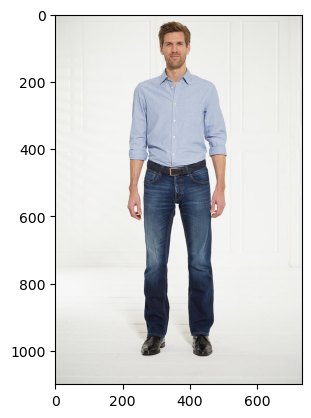

In [3]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

In [4]:
model = Wholebody(mode="lightweight", backend="onnxruntime", device="cpu")

load /home/topiary-pc/.cache/rtmlib/hub/checkpoints/yolox_tiny_8xb8-300e_humanart-6f3252f9.onnx with onnxruntime backend
load /home/topiary-pc/.cache/rtmlib/hub/checkpoints/rtmw-dw-l-m_simcc-cocktail14_270e-256x192_20231122.onnx with onnxruntime backend


2026-09-22 18:14:52.914715975 [W:onnxruntime:, graph.cc:4885 CleanUnusedInitializersAndNodeArgs] Removing initializer '1462'. It is not used by any node and should be removed from the model.
2026-09-22 18:14:52.914736563 [W:onnxruntime:, graph.cc:4885 CleanUnusedInitializersAndNodeArgs] Removing initializer '1470'. It is not used by any node and should be removed from the model.
2026-09-22 18:14:52.914746822 [W:onnxruntime:, graph.cc:4885 CleanUnusedInitializersAndNodeArgs] Removing initializer '1467'. It is not used by any node and should be removed from the model.


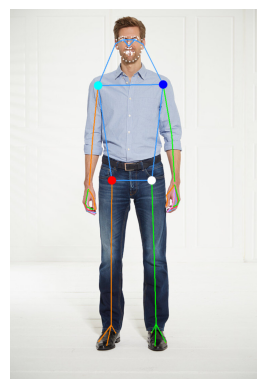

In [5]:
dets = model.det_model(img)
box = max(dets, key=lambda b: (b[2]-b[0])*(b[3]-b[1]))
keypoints, scores = model.pose_model(img, bboxes=[box])
k, s = keypoints[0], scores[0]
vis = draw_skeleton(img.copy(), keypoints, scores, kpt_thr=0.3)
cv2.circle(vis, tuple(map(int, k[5])), 12, (0,0,255), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, k[6])), 12, (0,255,255), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, k[11])), 12, (255,255,255), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, k[12])), 12, (255,0,0), -1, cv2.LINE_AA)

plt.imshow(vis)
plt.axis('off')
plt.show()

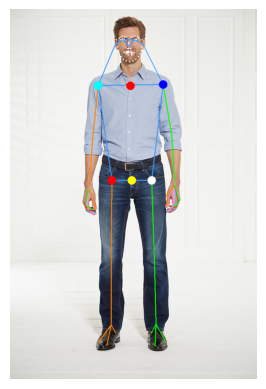

In [6]:
shoulder_midpoint = k[6] + abs(k[6] - k[5])/2
hip_midpoint = k[12] + abs(k[12] - k[11])/2
cv2.circle(vis, tuple(map(int, shoulder_midpoint)), 12, (255,0,0), -1, cv2.LINE_AA)
cv2.circle(vis, tuple(map(int, hip_midpoint)), 12, (255,255,0), -1, cv2.LINE_AA)
plt.imshow(vis)
plt.axis('off')
plt.show()

In [ ]:
he